# 🚗 Vehicle Detection dengan YOLOv8s

## Deteksi dan Counting Kendaraan (Bus, Car, Van)

**Model:** YOLOv8s (Small)

**Dataset:** Roboflow Vehicle Detection

**Source:** https://universe.roboflow.com/personal-project-kej16/vehicle-detection-vznzd-dkl8g

---

### 📋 Tahapan:
1. Setup & Instalasi Library
2. Pengecekan Hardware
3. Download Dataset dari Roboflow
4. Exploratory Data Analysis (EDA)
5. Pipeline Data Processing
6. Training Model YOLOv8s dengan Augmentasi
7. Evaluasi Model
8. Prediksi Test Set
9. Sistem Vehicle Counting
10. Export Model untuk Deployment

---

### ⚠️ PENTING:
- **Runtime:** GPU (T4) - Runtime → Change runtime type → GPU
- **API Key:** Ganti `YOUR_API_KEY_HERE` dengan API key Roboflow Anda
- **Dapatkan API Key:** https://app.roboflow.com/settings/api
- **Waktu Training:** ~2-3 jam untuk 100 epochs

---

In [ ]:
# =====================================================================================================
# VEHICLE DETECTION WITH YOLOV8S
# Project: Deteksi dan Counting Kendaraan (Bus, Car, Van)
# Model: YOLOv8s (Small - Balance antara speed dan accuracy)
# =====================================================================================================

# =====================================================================================================
# 1. SETUP & INSTALASI LIBRARY
# =====================================================================================================

print("="*80)
print("INSTALASI LIBRARY")
print("="*80)

%!pip install ultralytics roboflow pandas matplotlib seaborn pillow opencv-python pyyaml scikit-learn -q

print("✓ Instalasi library selesai")

# Import library
import os
import yaml
import shutil
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import cv2
from collections import Counter
import torch
from ultralytics import YOLO
import glob
from datetime import datetime
import json
from roboflow import Roboflow
from google.colab import files,userdata

# Set style untuk visualisasi
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 10

print("✓ Import library berhasil")

INSTALASI LIBRARY
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 63.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 19.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 86.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 128.9 MB/s eta 0:00:00
✓ Instalasi library selesai
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
✓ Import library berhasil


In [2]:
# =====================================================================================================
# 2. PENGECEKAN HARDWARE
# =====================================================================================================

print("\n" + "="*80)
print("INFORMASI HARDWARE")
print("="*80)

# Cek GPU
if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    gpu_memory = torch.cuda.get_device_properties(0).total_memory / 1e9
    cuda_version = torch.version.cuda
    print(f"✓ GPU Terdeteksi")
    print(f"  • Nama GPU: {gpu_name}")
    print(f"  • CUDA Version: {cuda_version}")
    print(f"  • GPU Memory: {gpu_memory:.2f} GB")
    device = 0
else:
    print("✗ GPU tidak tersedia, menggunakan CPU")
    print("  PERINGATAN: Training akan sangat lambat tanpa GPU!")
    device = 'cpu'

# Cek CPU
import multiprocessing
cpu_cores = multiprocessing.cpu_count()
print(f"\n✓ CPU Information")
print(f"  • CPU Cores: {cpu_cores}")

# Cek RAM
import psutil
ram_gb = psutil.virtual_memory().total / 1e9
ram_available = psutil.virtual_memory().available / 1e9
print(f"\n✓ RAM Information")
print(f"  • Total RAM: {ram_gb:.2f} GB")
print(f"  • Available RAM: {ram_available:.2f} GB")

print("="*80)


INFORMASI HARDWARE
✓ GPU Terdeteksi
  • Nama GPU: Tesla T4
  • CUDA Version: 12.6
  • GPU Memory: 15.83 GB

✓ CPU Information
  • CPU Cores: 2

✓ RAM Information
  • Total RAM: 13.61 GB
  • Available RAM: 11.72 GB


In [ ]:
# =====================================================================================================
# 3. DOWNLOAD DATASET DARI ROBOFLOW
# =====================================================================================================

print("\n" + "="*80)
print("DOWNLOAD DATASET DARI ROBOFLOW")
print("="*80)

# ⚠️ IMPORTANT: GANTI DENGAN API KEY ANDA!
# Dapatkan API key di: https://app.roboflow.com/settings/api
ROBOFLOW_API_KEY = userdata.get('ROBOFLOW_API_KEY')  # <-- GANTI INI!

print("Menginisialisasi Roboflow...")

try:
    rf = Roboflow(api_key=ROBOFLOW_API_KEY)

    # Access workspace dan project
    project = rf.workspace("personal-project-kej16").project("vehicle-detection-vznzd-dkl8g")

    # Download dataset versi 1 dalam format YOLOv8
    print("Mendownload dataset...")
    print("URL: https://universe.roboflow.com/personal-project-kej16/vehicle-detection-vznzd-dkl8g")

    dataset = project.version(1).download("yolov8")

    DATASET_PATH = dataset.location
    print(f"\n✓ Dataset berhasil didownload!")
    print(f"✓ Lokasi dataset: {DATASET_PATH}")

except Exception as e:
    print(f"\n❌ Error saat download dataset: {str(e)}")
    print("\nSOLUSI:")
    print("1. Pastikan API key sudah diganti dengan API key Anda")
    print("2. Dapatkan API key di: https://app.roboflow.com/settings/api")
    print("3. Pastikan koneksi internet stabil")
    raise


DOWNLOAD DATASET DARI ROBOFLOW
Menginisialisasi Roboflow...
loading Roboflow workspace...
loading Roboflow project...
Mendownload dataset...
URL: https://universe.roboflow.com/personal-project-kej16/vehicle-detection-vznzd-dkl8g



Extracting Dataset Version Zip to vehicle-detection-1 in yolov8:: 100%|██████████| 19462/19462 [00:03<00:00, 6261.35it/s]



✓ Dataset berhasil didownload!
✓ Lokasi dataset: /content/vehicle-detection-1


## 📊 Exploratory Data Analysis (EDA)

Pada bagian ini kita akan melakukan analisis mendalam terhadap dataset:
- Distribusi data per split (train/valid/test)
- Distribusi class (bus/car/van)
- Analisis ukuran gambar
- Visualisasi sample data dengan annotations
- Analisis bounding box


EXPLORATORY DATA ANALYSIS (EDA)

📋 INFORMASI DATASET
--------------------------------------------------------------------------------
Dataset Name    : Vehicle Detection
Classes         : ['bus', 'car', 'van']
Number of Classes: 3
Train Path      : ../train/images
Valid Path      : ../valid/images
Test Path       : ../test/images
Source          : Roboflow
License         : CC BY 4.0

--------------------------------------------------------------------------------
ANALISIS JUMLAH DATA
--------------------------------------------------------------------------------
Train    - Images: 9218, Labels: 9218, Status: ✓
Valid    - Images:  287, Labels:  287, Status: ✓
Test     - Images:  220, Labels:  220, Status: ✓

TOTAL    - Images: 9725, Labels: 9725


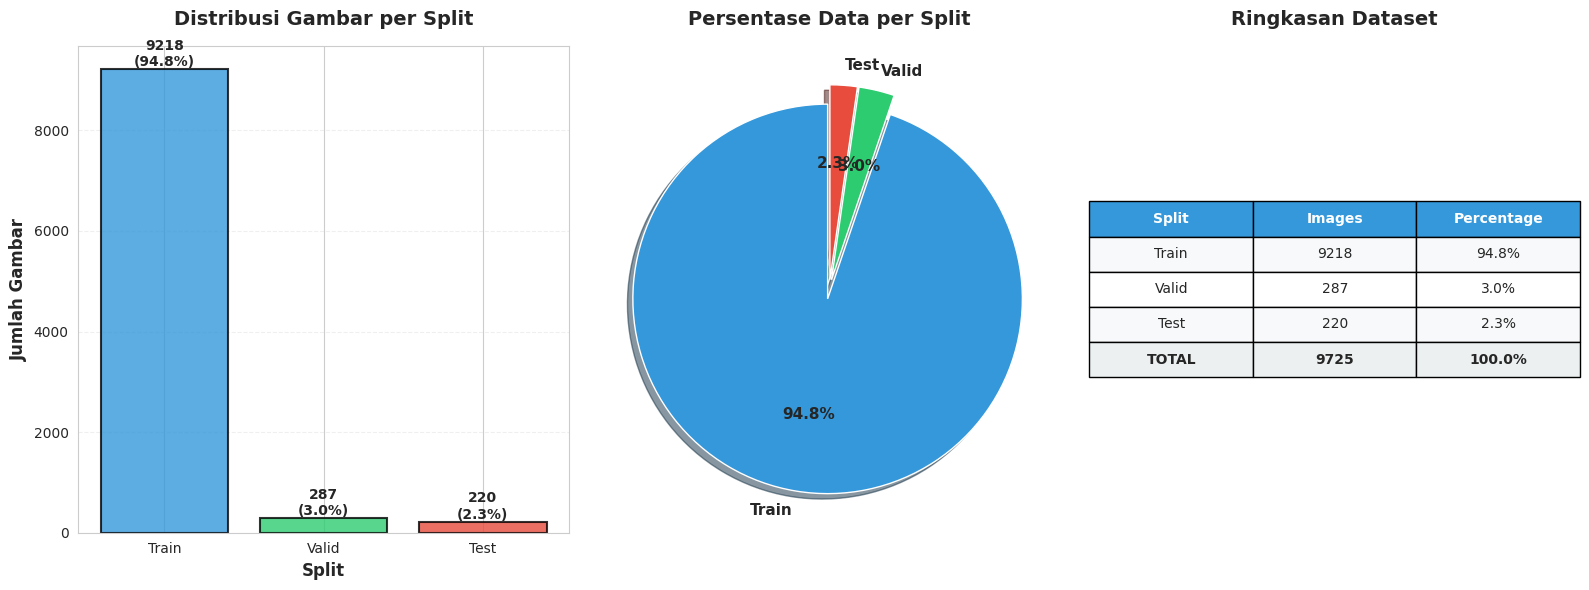


✓ Visualisasi distribusi data disimpan: 01_data_distribution.png

--------------------------------------------------------------------------------
ANALISIS DISTRIBUSI CLASS
--------------------------------------------------------------------------------

Distribusi Objek per Split:
--------------------------------------------------------------------------------

TRAIN:
  • bus      :  4476 objek ( 24.2%)
  • car      : 10739 objek ( 58.1%)
  • van      :  3279 objek ( 17.7%)
  • Total    : 18494 objek

VALID:
  • bus      :   113 objek ( 26.5%)
  • car      :   279 objek ( 65.3%)
  • van      :    35 objek (  8.2%)
  • Total    :   427 objek

TEST:
  • bus      :   109 objek ( 26.4%)
  • car      :   236 objek ( 57.1%)
  • van      :    68 objek ( 16.5%)
  • Total    :   413 objek

TOTAL KESELURUHAN:
  • bus      :  4698 objek ( 24.3%)
  • car      : 11254 objek ( 58.2%)
  • van      :  3382 objek ( 17.5%)
  • Total    : 19334 objek


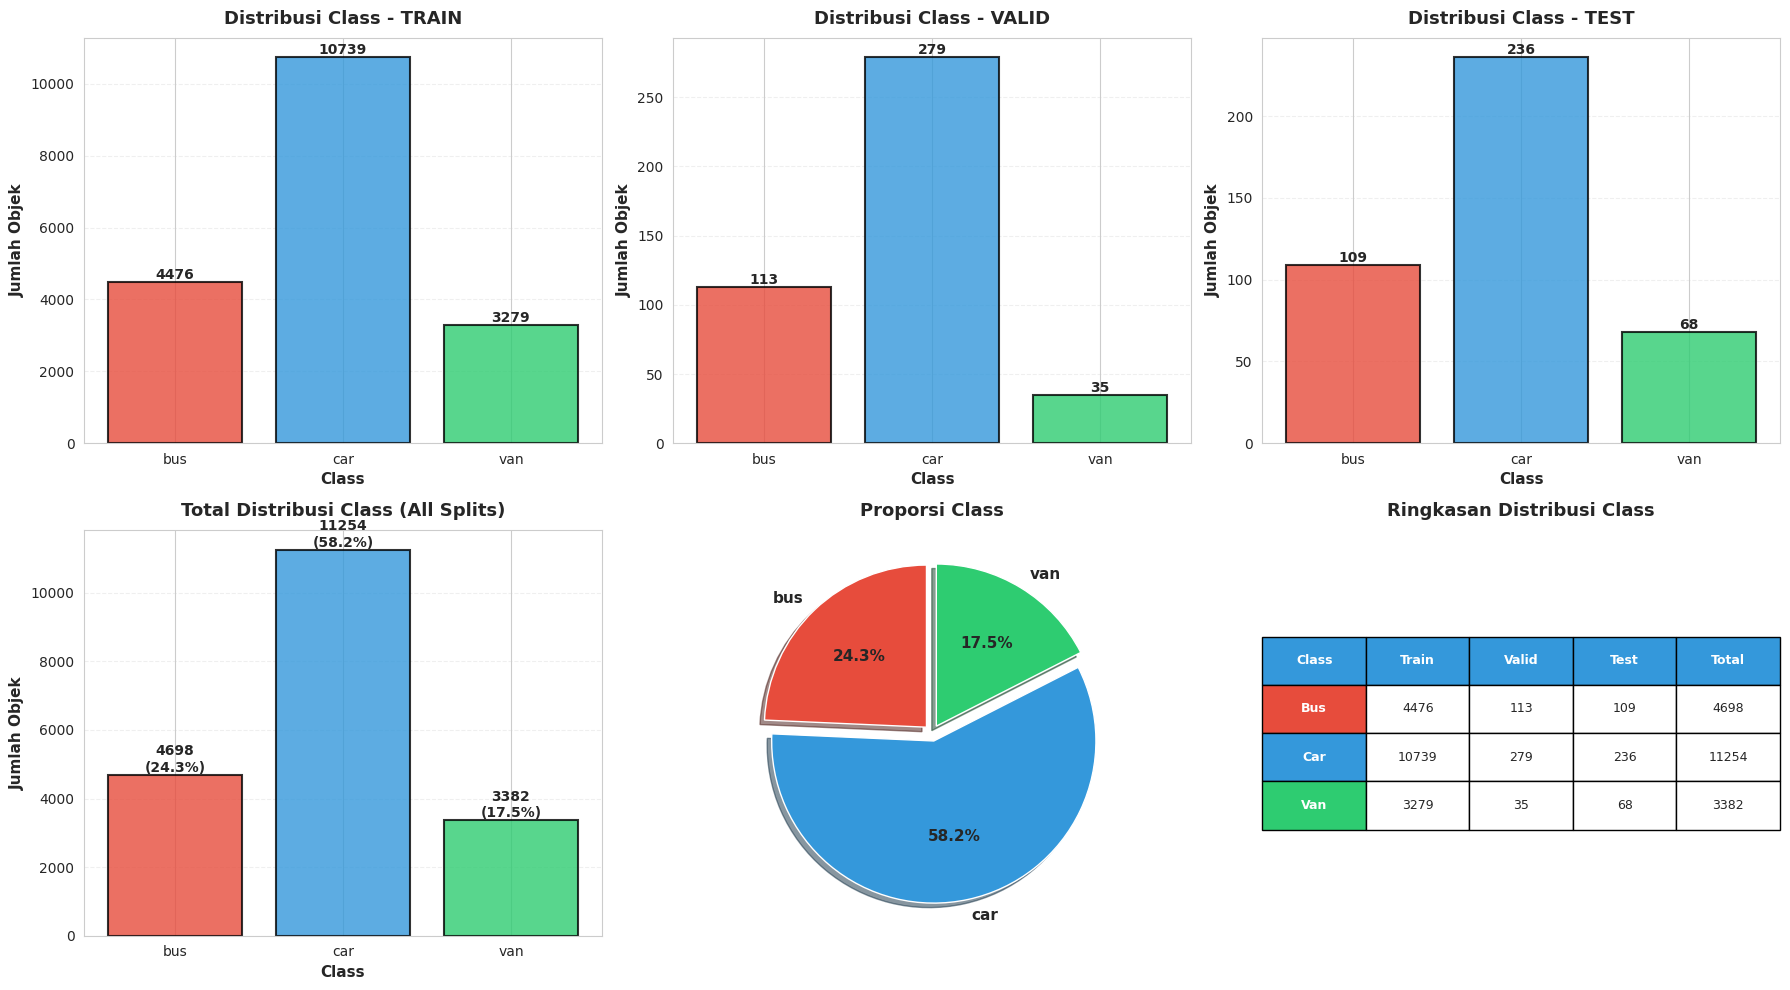


✓ Visualisasi distribusi class disimpan: 02_class_distribution.png

--------------------------------------------------------------------------------
ANALISIS UKURAN GAMBAR
--------------------------------------------------------------------------------

Analisis Ukuran Gambar (sample per split):
--------------------------------------------------------------------------------

TRAIN (sample: 200 images):
  Width  - Min:  180, Max: 1600, Mean:  648.7, Std:  315.1
  Height - Min:  111, Max: 2048, Mean:  527.7, Std:  283.0
  Aspect - Min: 0.562, Max: 2.813, Mean: 1.308

VALID (sample: 200 images):
  Width  - Min:  200, Max: 2048, Mean:  642.5, Std:  301.7
  Height - Min:  128, Max: 2048, Mean:  583.3, Std:  311.8
  Aspect - Min: 0.562, Max: 3.070, Mean: 1.214

TEST (sample: 200 images):
  Width  - Min:  195, Max: 2048, Mean:  644.0, Std:  327.3
  Height - Min:  112, Max: 2048, Mean:  525.6, Std:  306.8
  Aspect - Min: 0.562, Max: 4.018, Mean: 1.342


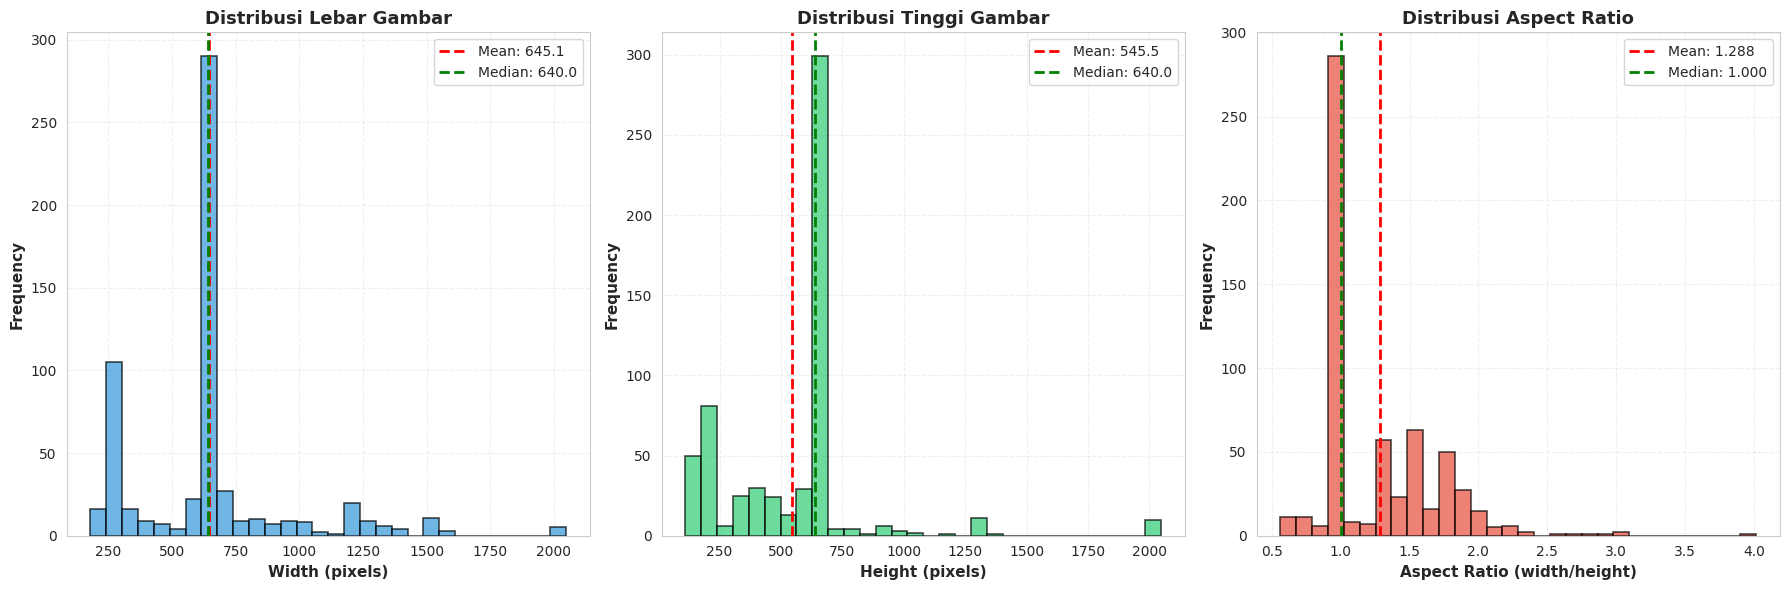


✓ Visualisasi ukuran gambar disimpan: 03_image_size_distribution.png

--------------------------------------------------------------------------------
VISUALISASI SAMPLE DATA
--------------------------------------------------------------------------------

Membuat visualisasi sample data dari TRAIN split...


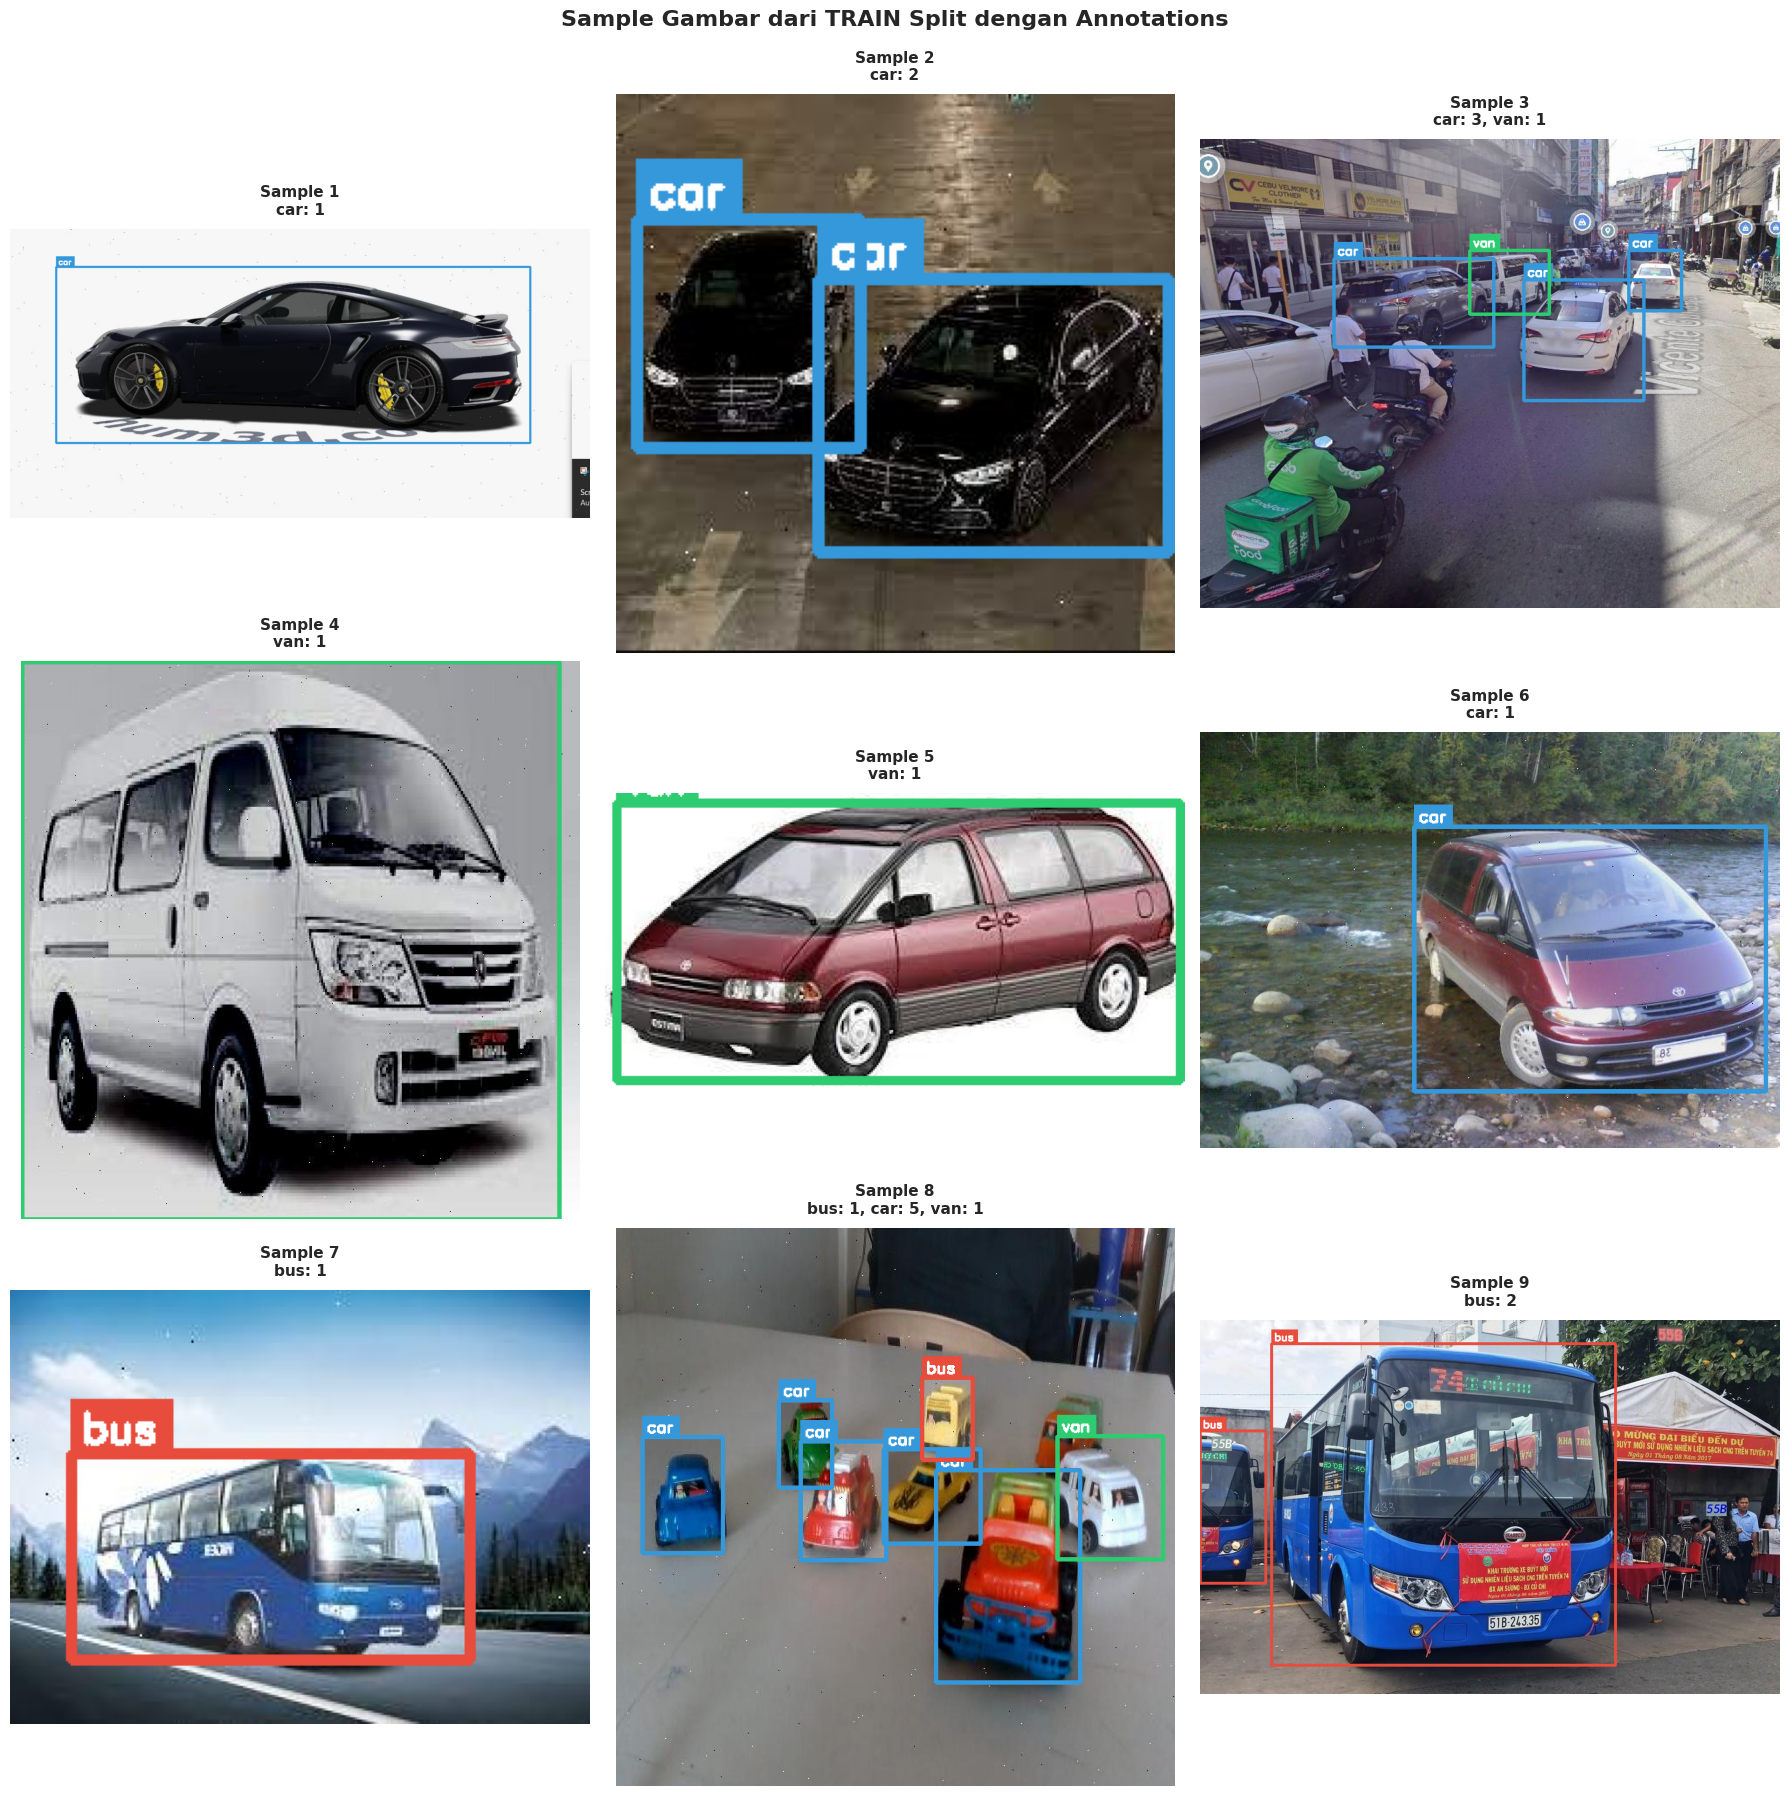

✓ Visualisasi sample data disimpan: 04_sample_images_train.png

--------------------------------------------------------------------------------
ANALISIS BOUNDING BOX
--------------------------------------------------------------------------------

Analisis ukuran Bounding Box (TRAIN split):
--------------------------------------------------------------------------------

BUS:
  Count     : 4476
  Width     : Min=3.0, Max=1540.0, Mean=214.3
  Height    : Min=11.9, Max=1240.0, Mean=197.2
  Area      : Min=57.0, Max=1502943.0, Mean=70683.1

CAR:
  Count     : 10739
  Width     : Min=4.0, Max=1500.0, Mean=211.0
  Height    : Min=2.0, Max=1065.5, Mean=175.6
  Area      : Min=21.0, Max=1397403.2, Mean=61592.8

VAN:
  Count     : 3279
  Width     : Min=2.0, Max=1926.0, Mean=270.3
  Height    : Min=0.7, Max=912.0, Mean=198.5
  Area      : Min=1.4, Max=1756512.0, Mean=80252.4


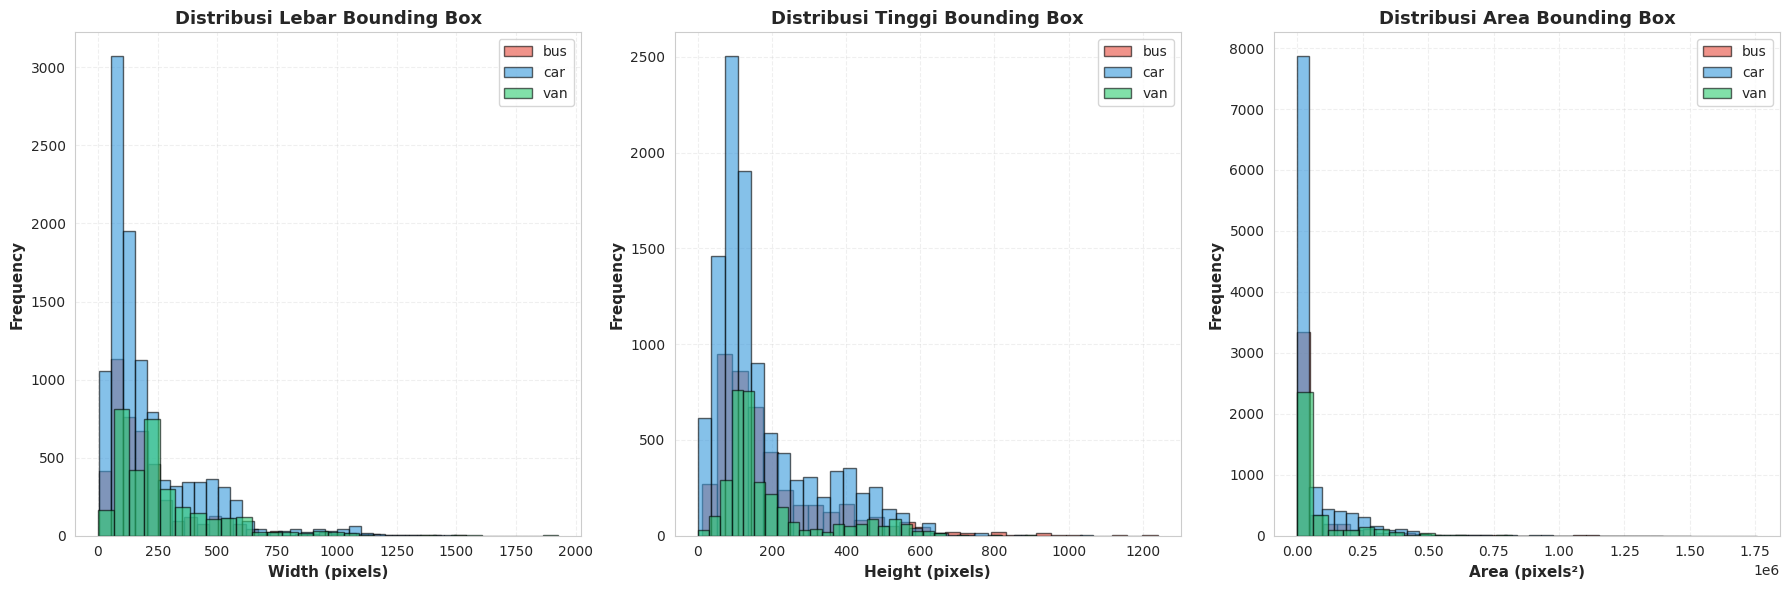


✓ Visualisasi analisis bounding box disimpan: 05_bbox_analysis.png


In [4]:
# =====================================================================================================
# 4. EXPLORATORY DATA ANALYSIS (EDA)
# =====================================================================================================

print("\n" + "="*80)
print("EXPLORATORY DATA ANALYSIS (EDA)")
print("="*80)

# Fungsi untuk membaca data.yaml
def load_yaml(yaml_path):
    with open(yaml_path, 'r') as f:
        data = yaml.safe_load(f)
    return data

# Load data.yaml
yaml_path = os.path.join(DATASET_PATH, "data.yaml")
data_config = load_yaml(yaml_path)

print("\n📋 INFORMASI DATASET")
print("-" * 80)
print(f"Dataset Name    : Vehicle Detection")
print(f"Classes         : {data_config['names']}")
print(f"Number of Classes: {data_config['nc']}")
print(f"Train Path      : {data_config['train']}")
print(f"Valid Path      : {data_config['val']}")
print(f"Test Path       : {data_config['test']}")
print(f"Source          : Roboflow")
print(f"License         : CC BY 4.0")

# =====================================================================================================
# 4.1 ANALISIS JUMLAH DATA
# =====================================================================================================

print("\n" + "-"*80)
print("ANALISIS JUMLAH DATA")
print("-" * 80)

def count_files(base_path, split):
    """Hitung jumlah images dan labels"""
    images_path = os.path.join(base_path, split, "images")
    labels_path = os.path.join(base_path, split, "labels")

    images = []
    labels = []

    if os.path.exists(images_path):
        images = glob.glob(os.path.join(images_path, "*.*"))

    if os.path.exists(labels_path):
        labels = glob.glob(os.path.join(labels_path, "*.txt"))

    return len(images), len(labels)

# Hitung jumlah data per split
splits = ['train', 'valid', 'test']
data_summary = []

for split in splits:
    n_images, n_labels = count_files(DATASET_PATH, split)
    data_summary.append({
        'Split': split.capitalize(),
        'Images': n_images,
        'Labels': n_labels,
        'Status': '✓' if n_images == n_labels else '✗'
    })
    print(f"{split.capitalize():8} - Images: {n_images:4}, Labels: {n_labels:4}, Status: {'✓' if n_images == n_labels else '✗'}")

df_summary = pd.DataFrame(data_summary)

# Total dataset
total_images = df_summary['Images'].sum()
total_labels = df_summary['Labels'].sum()
print(f"\n{'TOTAL':8} - Images: {total_images:4}, Labels: {total_labels:4}")

# Visualisasi distribusi data
fig = plt.figure(figsize=(16, 6))

# Plot 1: Bar chart jumlah gambar per split
ax1 = plt.subplot(1, 3, 1)
colors_bar = ['#3498db', '#2ecc71', '#e74c3c']
bars = ax1.bar(df_summary['Split'], df_summary['Images'], color=colors_bar, alpha=0.8, edgecolor='black', linewidth=1.5)
ax1.set_title('Distribusi Gambar per Split', fontsize=14, fontweight='bold', pad=15)
ax1.set_xlabel('Split', fontsize=12, fontweight='bold')
ax1.set_ylabel('Jumlah Gambar', fontsize=12, fontweight='bold')
ax1.grid(axis='y', alpha=0.3, linestyle='--')
ax1.set_axisbelow(True)

# Tambahkan nilai di atas bar
for i, (bar, v) in enumerate(zip(bars, df_summary['Images'])):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
             f'{v}\n({v/total_images*100:.1f}%)',
             ha='center', va='bottom', fontweight='bold', fontsize=10)

# Plot 2: Pie chart persentase data
ax2 = plt.subplot(1, 3, 2)
explode = (0.05, 0.05, 0.05)
wedges, texts, autotexts = ax2.pie(df_summary['Images'],
                                     labels=df_summary['Split'],
                                     autopct='%1.1f%%',
                                     colors=colors_bar,
                                     explode=explode,
                                     startangle=90,
                                     shadow=True,
                                     textprops={'fontweight': 'bold', 'fontsize': 11})
ax2.set_title('Persentase Data per Split', fontsize=14, fontweight='bold', pad=15)

# Plot 3: Table summary
ax3 = plt.subplot(1, 3, 3)
ax3.axis('tight')
ax3.axis('off')

table_data = []
for _, row in df_summary.iterrows():
    table_data.append([
        row['Split'],
        f"{row['Images']}",
        f"{row['Images']/total_images*100:.1f}%"
    ])
table_data.append(['TOTAL', f"{total_images}", '100.0%'])

table = ax3.table(cellText=table_data,
                  colLabels=['Split', 'Images', 'Percentage'],
                  cellLoc='center',
                  loc='center',
                  colColours=['#3498db']*3)
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2)

# Style header
for i in range(3):
    table[(0, i)].set_facecolor('#3498db')
    table[(0, i)].set_text_props(weight='bold', color='white')

# Style rows
for i in range(1, len(table_data) + 1):
    for j in range(3):
        if i == len(table_data):  # Total row
            table[(i, j)].set_facecolor('#ecf0f1')
            table[(i, j)].set_text_props(weight='bold')
        else:
            table[(i, j)].set_facecolor('#ffffff' if i % 2 == 0 else '#f8f9fa')

ax3.set_title('Ringkasan Dataset', fontsize=14, fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig('01_data_distribution.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

print("\n✓ Visualisasi distribusi data disimpan: 01_data_distribution.png")

# =====================================================================================================
# 4.2 ANALISIS DISTRIBUSI CLASS
# =====================================================================================================

print("\n" + "-"*80)
print("ANALISIS DISTRIBUSI CLASS")
print("-" * 80)

def count_classes_in_split(base_path, split, class_names):
    """Hitung jumlah objek per class dalam setiap split"""
    labels_path = os.path.join(base_path, split, "labels")
    class_counts = {name: 0 for name in class_names}
    total_objects = 0

    if os.path.exists(labels_path):
        for label_file in glob.glob(os.path.join(labels_path, "*.txt")):
            with open(label_file, 'r') as f:
                for line in f:
                    if line.strip():
                        class_id = int(line.split()[0])
                        if class_id < len(class_names):
                            class_counts[class_names[class_id]] += 1
                            total_objects += 1

    return class_counts, total_objects

# Analisis distribusi class per split
class_distribution = {}
all_class_totals = {name: 0 for name in data_config['names']}

print("\nDistribusi Objek per Split:")
print("-" * 80)

for split in splits:
    class_counts, total = count_classes_in_split(DATASET_PATH, split, data_config['names'])
    class_distribution[split] = class_counts

    print(f"\n{split.upper()}:")
    for cls, count in class_counts.items():
        percentage = (count / total * 100) if total > 0 else 0
        print(f"  • {cls:8} : {count:5} objek ({percentage:5.1f}%)")
        all_class_totals[cls] += count
    print(f"  • Total    : {total:5} objek")

# Total keseluruhan
total_all_objects = sum(all_class_totals.values())
print(f"\nTOTAL KESELURUHAN:")
for cls, count in all_class_totals.items():
    percentage = (count / total_all_objects * 100) if total_all_objects > 0 else 0
    print(f"  • {cls:8} : {count:5} objek ({percentage:5.1f}%)")
print(f"  • Total    : {total_all_objects:5} objek")

# Visualisasi distribusi class
fig = plt.figure(figsize=(18, 10))

# Plot distribusi per split
for idx, split in enumerate(splits):
    ax = plt.subplot(2, 3, idx + 1)

    classes = list(class_distribution[split].keys())
    counts = list(class_distribution[split].values())
    colors_class = ['#e74c3c', '#3498db', '#2ecc71']

    bars = ax.bar(classes, counts, color=colors_class, alpha=0.8, edgecolor='black', linewidth=1.5)
    ax.set_title(f'Distribusi Class - {split.upper()}', fontsize=13, fontweight='bold', pad=10)
    ax.set_xlabel('Class', fontsize=11, fontweight='bold')
    ax.set_ylabel('Jumlah Objek', fontsize=11, fontweight='bold')
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.set_axisbelow(True)

    # Tambahkan nilai di atas bar
    for bar, count in zip(bars, counts):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{count}',
                ha='center', va='bottom', fontweight='bold', fontsize=10)

# Plot total distribusi class
ax4 = plt.subplot(2, 3, 4)
classes_total = list(all_class_totals.keys())
counts_total = list(all_class_totals.values())

bars = ax4.bar(classes_total, counts_total, color=colors_class, alpha=0.8, edgecolor='black', linewidth=1.5)
ax4.set_title('Total Distribusi Class (All Splits)', fontsize=13, fontweight='bold', pad=10)
ax4.set_xlabel('Class', fontsize=11, fontweight='bold')
ax4.set_ylabel('Jumlah Objek', fontsize=11, fontweight='bold')
ax4.grid(axis='y', alpha=0.3, linestyle='--')
ax4.set_axisbelow(True)

for bar, count in zip(bars, counts_total):
    height = bar.get_height()
    percentage = (count / total_all_objects * 100)
    ax4.text(bar.get_x() + bar.get_width()/2., height,
            f'{count}\n({percentage:.1f}%)',
            ha='center', va='bottom', fontweight='bold', fontsize=10)

# Plot pie chart total
ax5 = plt.subplot(2, 3, 5)
explode = (0.05, 0.05, 0.05)
wedges, texts, autotexts = ax5.pie(counts_total,
                                     labels=classes_total,
                                     autopct='%1.1f%%',
                                     colors=colors_class,
                                     explode=explode,
                                     startangle=90,
                                     shadow=True,
                                     textprops={'fontweight': 'bold', 'fontsize': 11})
ax5.set_title('Proporsi Class', fontsize=13, fontweight='bold', pad=10)

# Table summary class
ax6 = plt.subplot(2, 3, 6)
ax6.axis('tight')
ax6.axis('off')

table_data_class = []
for cls in classes_total:
    train_count = class_distribution['train'][cls]
    valid_count = class_distribution['valid'][cls]
    test_count = class_distribution['test'][cls]
    total_count = all_class_totals[cls]

    table_data_class.append([
        cls.capitalize(),
        f"{train_count}",
        f"{valid_count}",
        f"{test_count}",
        f"{total_count}"
    ])

table_class = ax6.table(cellText=table_data_class,
                        colLabels=['Class', 'Train', 'Valid', 'Test', 'Total'],
                        cellLoc='center',
                        loc='center',
                        colColours=['#3498db']*5)
table_class.auto_set_font_size(False)
table_class.set_fontsize(9)
table_class.scale(1, 2.5)

# Style header
for i in range(5):
    table_class[(0, i)].set_facecolor('#3498db')
    table_class[(0, i)].set_text_props(weight='bold', color='white')

# Style rows dengan warna sesuai class
color_map = {'Bus': '#e74c3c', 'Car': '#3498db', 'Van': '#2ecc71'}
for i in range(1, len(table_data_class) + 1):
    class_name = table_data_class[i-1][0]
    row_color = color_map.get(class_name, '#ffffff')
    for j in range(5):
        table_class[(i, j)].set_facecolor(row_color if j == 0 else '#ffffff')
        if j == 0:
            table_class[(i, j)].set_text_props(weight='bold', color='white')

ax6.set_title('Ringkasan Distribusi Class', fontsize=13, fontweight='bold', pad=10)

plt.tight_layout()
plt.savefig('02_class_distribution.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

print("\n✓ Visualisasi distribusi class disimpan: 02_class_distribution.png")

# =====================================================================================================
# 4.3 ANALISIS UKURAN GAMBAR
# =====================================================================================================

print("\n" + "-"*80)
print("ANALISIS UKURAN GAMBAR")
print("-" * 80)

def analyze_image_sizes(base_path, split, sample_size=200):
    """Analisis ukuran gambar (width dan height)"""
    images_path = os.path.join(base_path, split, "images")
    widths, heights, aspects = [], [], []

    if os.path.exists(images_path):
        image_files = glob.glob(os.path.join(images_path, "*.*"))
        # Sample jika terlalu banyak
        if len(image_files) > sample_size:
            import random
            image_files = random.sample(image_files, sample_size)

        for img_file in image_files:
            try:
                img = Image.open(img_file)
                widths.append(img.width)
                heights.append(img.height)
                aspects.append(img.width / img.height)
            except:
                continue

    return widths, heights, aspects

# Analisis untuk setiap split
all_widths, all_heights, all_aspects = [], [], []

print("\nAnalisis Ukuran Gambar (sample per split):")
print("-" * 80)

for split in splits:
    widths, heights, aspects = analyze_image_sizes(DATASET_PATH, split, sample_size=200)

    if widths:
        all_widths.extend(widths)
        all_heights.extend(heights)
        all_aspects.extend(aspects)

        print(f"\n{split.upper()} (sample: {len(widths)} images):")
        print(f"  Width  - Min: {min(widths):4}, Max: {max(widths):4}, Mean: {np.mean(widths):6.1f}, Std: {np.std(widths):6.1f}")
        print(f"  Height - Min: {min(heights):4}, Max: {max(heights):4}, Mean: {np.mean(heights):6.1f}, Std: {np.std(heights):6.1f}")
        print(f"  Aspect - Min: {min(aspects):.3f}, Max: {max(aspects):.3f}, Mean: {np.mean(aspects):.3f}")

# Visualisasi ukuran gambar
fig = plt.figure(figsize=(18, 6))

# Plot distribusi width
ax1 = plt.subplot(1, 3, 1)
ax1.hist(all_widths, bins=30, color='#3498db', alpha=0.7, edgecolor='black', linewidth=1.2)
ax1.axvline(np.mean(all_widths), color='red', linestyle='--', linewidth=2, label=f'Mean: {np.mean(all_widths):.1f}')
ax1.axvline(np.median(all_widths), color='green', linestyle='--', linewidth=2, label=f'Median: {np.median(all_widths):.1f}')
ax1.set_title('Distribusi Lebar Gambar', fontsize=13, fontweight='bold')
ax1.set_xlabel('Width (pixels)', fontsize=11, fontweight='bold')
ax1.set_ylabel('Frequency', fontsize=11, fontweight='bold')
ax1.legend()
ax1.grid(alpha=0.3, linestyle='--')

# Plot distribusi height
ax2 = plt.subplot(1, 3, 2)
ax2.hist(all_heights, bins=30, color='#2ecc71', alpha=0.7, edgecolor='black', linewidth=1.2)
ax2.axvline(np.mean(all_heights), color='red', linestyle='--', linewidth=2, label=f'Mean: {np.mean(all_heights):.1f}')
ax2.axvline(np.median(all_heights), color='green', linestyle='--', linewidth=2, label=f'Median: {np.median(all_heights):.1f}')
ax2.set_title('Distribusi Tinggi Gambar', fontsize=13, fontweight='bold')
ax2.set_xlabel('Height (pixels)', fontsize=11, fontweight='bold')
ax2.set_ylabel('Frequency', fontsize=11, fontweight='bold')
ax2.legend()
ax2.grid(alpha=0.3, linestyle='--')

# Plot distribusi aspect ratio
ax3 = plt.subplot(1, 3, 3)
ax3.hist(all_aspects, bins=30, color='#e74c3c', alpha=0.7, edgecolor='black', linewidth=1.2)
ax3.axvline(np.mean(all_aspects), color='red', linestyle='--', linewidth=2, label=f'Mean: {np.mean(all_aspects):.3f}')
ax3.axvline(np.median(all_aspects), color='green', linestyle='--', linewidth=2, label=f'Median: {np.median(all_aspects):.3f}')
ax3.set_title('Distribusi Aspect Ratio', fontsize=13, fontweight='bold')
ax3.set_xlabel('Aspect Ratio (width/height)', fontsize=11, fontweight='bold')
ax3.set_ylabel('Frequency', fontsize=11, fontweight='bold')
ax3.legend()
ax3.grid(alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig('03_image_size_distribution.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

print("\n✓ Visualisasi ukuran gambar disimpan: 03_image_size_distribution.png")

# =====================================================================================================
# 4.4 VISUALISASI SAMPLE DATA DENGAN ANNOTATIONS
# =====================================================================================================

print("\n" + "-"*80)
print("VISUALISASI SAMPLE DATA")
print("-" * 80)

def visualize_samples(base_path, split, class_names, n_samples=9):
    """Visualisasi sample gambar dengan bounding boxes"""
    images_path = os.path.join(base_path, split, "images")
    labels_path = os.path.join(base_path, split, "labels")

    if not os.path.exists(images_path):
        print(f"Path tidak ditemukan: {images_path}")
        return

    image_files = glob.glob(os.path.join(images_path, "*.*"))

    if len(image_files) < n_samples:
        n_samples = len(image_files)

    # Ambil random samples
    import random
    image_files = random.sample(image_files, n_samples)

    # Setup plot
    rows = 3
    cols = 3
    fig, axes = plt.subplots(rows, cols, figsize=(18, 18))
    axes = axes.ravel()

    # Warna untuk setiap class
    color_map = {
        'bus': (231, 76, 60),    # Merah
        'car': (52, 152, 219),   # Biru
        'van': (46, 204, 113)    # Hijau
    }

    for idx, img_path in enumerate(image_files):
        if idx >= n_samples:
            break

        # Load image
        img = cv2.imread(img_path)
        if img is None:
            continue

        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        h, w = img.shape[:2]

        # Load labels
        base_name = os.path.splitext(os.path.basename(img_path))[0]
        label_file = os.path.join(labels_path, base_name + '.txt')

        objects_count = {name: 0 for name in class_names}

        if os.path.exists(label_file):
            with open(label_file, 'r') as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) >= 5:
                        class_id = int(parts[0])
                        x_center, y_center, width, height = map(float, parts[1:5])

                        # Convert YOLO format ke pixel coordinates
                        x1 = int((x_center - width/2) * w)
                        y1 = int((y_center - height/2) * h)
                        x2 = int((x_center + width/2) * w)
                        y2 = int((y_center + height/2) * h)

                        # Pastikan koordinat dalam batas gambar
                        x1, y1 = max(0, x1), max(0, y1)
                        x2, y2 = min(w, x2), min(h, y2)

                        if class_id < len(class_names):
                            class_name = class_names[class_id]
                            objects_count[class_name] += 1
                            color = color_map.get(class_name, (255, 255, 255))

                            # Draw bounding box
                            cv2.rectangle(img, (x1, y1), (x2, y2), color, 3)

                            # Draw label background
                            label_text = f'{class_name}'
                            font = cv2.FONT_HERSHEY_SIMPLEX
                            font_scale = 0.6
                            thickness = 2
                            (text_width, text_height), _ = cv2.getTextSize(label_text, font, font_scale, thickness)

                            cv2.rectangle(img, (x1, y1 - text_height - 10), (x1 + text_width + 10, y1), color, -1)
                            cv2.putText(img, label_text, (x1 + 5, y1 - 5), font, font_scale, (255, 255, 255), thickness)

        # Plot
        axes[idx].imshow(img)
        axes[idx].axis('off')

        # Title dengan jumlah objek
        count_str = ', '.join([f"{k}: {v}" for k, v in objects_count.items() if v > 0])
        if not count_str:
            count_str = "No objects"

        axes[idx].set_title(f'Sample {idx+1}\n{count_str}',
                           fontweight='bold', fontsize=11, pad=10)

    # Hide unused subplots
    for idx in range(n_samples, len(axes)):
        axes[idx].axis('off')

    plt.suptitle(f'Sample Gambar dari {split.upper()} Split dengan Annotations',
                 fontsize=16, fontweight='bold', y=0.995)
    plt.tight_layout()
    plt.savefig(f'04_sample_images_{split}.png', dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()

# Visualisasi dari train split
print("\nMembuat visualisasi sample data dari TRAIN split...")
visualize_samples(DATASET_PATH, 'train', data_config['names'], n_samples=9)

print("✓ Visualisasi sample data disimpan: 04_sample_images_train.png")

# =====================================================================================================
# 4.5 ANALISIS BOUNDING BOX
# =====================================================================================================

print("\n" + "-"*80)
print("ANALISIS BOUNDING BOX")
print("-" * 80)

def analyze_bbox_sizes(base_path, split, class_names):
    """Analisis ukuran bounding box"""
    labels_path = os.path.join(base_path, split, "labels")
    images_path = os.path.join(base_path, split, "images")

    bbox_data = {name: {'widths': [], 'heights': [], 'areas': []} for name in class_names}

    if os.path.exists(labels_path):
        for label_file in glob.glob(os.path.join(labels_path, "*.txt")):
            # Get image dimensions
            base_name = os.path.splitext(os.path.basename(label_file))[0]
            img_files = glob.glob(os.path.join(images_path, base_name + ".*"))

            if img_files:
                try:
                    img = Image.open(img_files[0])
                    img_w, img_h = img.size

                    with open(label_file, 'r') as f:
                        for line in f:
                            parts = line.strip().split()
                            if len(parts) >= 5:
                                class_id = int(parts[0])
                                _, _, width, height = map(float, parts[1:5])

                                # Convert to pixels
                                width_px = width * img_w
                                height_px = height * img_h
                                area_px = width_px * height_px

                                if class_id < len(class_names):
                                    class_name = class_names[class_id]
                                    bbox_data[class_name]['widths'].append(width_px)
                                    bbox_data[class_name]['heights'].append(height_px)
                                    bbox_data[class_name]['areas'].append(area_px)
                except:
                    continue

    return bbox_data

# Analisis bbox untuk train split
print("\nAnalisis ukuran Bounding Box (TRAIN split):")
print("-" * 80)

bbox_stats = analyze_bbox_sizes(DATASET_PATH, 'train', data_config['names'])

for class_name in data_config['names']:
    widths = bbox_stats[class_name]['widths']
    heights = bbox_stats[class_name]['heights']
    areas = bbox_stats[class_name]['areas']

    if widths:
        print(f"\n{class_name.upper()}:")
        print(f"  Count     : {len(widths)}")
        print(f"  Width     : Min={min(widths):.1f}, Max={max(widths):.1f}, Mean={np.mean(widths):.1f}")
        print(f"  Height    : Min={min(heights):.1f}, Max={max(heights):.1f}, Mean={np.mean(heights):.1f}")
        print(f"  Area      : Min={min(areas):.1f}, Max={max(areas):.1f}, Mean={np.mean(areas):.1f}")

# Visualisasi bbox sizes
fig = plt.figure(figsize=(18, 6))

colors_class = ['#e74c3c', '#3498db', '#2ecc71']

# Plot 1: Width distribution
ax1 = plt.subplot(1, 3, 1)
for idx, class_name in enumerate(data_config['names']):
    widths = bbox_stats[class_name]['widths']
    if widths:
        ax1.hist(widths, bins=30, alpha=0.6, label=class_name, color=colors_class[idx], edgecolor='black')
ax1.set_title('Distribusi Lebar Bounding Box', fontsize=13, fontweight='bold')
ax1.set_xlabel('Width (pixels)', fontsize=11, fontweight='bold')
ax1.set_ylabel('Frequency', fontsize=11, fontweight='bold')
ax1.legend()
ax1.grid(alpha=0.3, linestyle='--')

# Plot 2: Height distribution
ax2 = plt.subplot(1, 3, 2)
for idx, class_name in enumerate(data_config['names']):
    heights = bbox_stats[class_name]['heights']
    if heights:
        ax2.hist(heights, bins=30, alpha=0.6, label=class_name, color=colors_class[idx], edgecolor='black')
ax2.set_title('Distribusi Tinggi Bounding Box', fontsize=13, fontweight='bold')
ax2.set_xlabel('Height (pixels)', fontsize=11, fontweight='bold')
ax2.set_ylabel('Frequency', fontsize=11, fontweight='bold')
ax2.legend()
ax2.grid(alpha=0.3, linestyle='--')

# Plot 3: Area distribution
ax3 = plt.subplot(1, 3, 3)
for idx, class_name in enumerate(data_config['names']):
    areas = bbox_stats[class_name]['areas']
    if areas:
        ax3.hist(areas, bins=30, alpha=0.6, label=class_name, color=colors_class[idx], edgecolor='black')
ax3.set_title('Distribusi Area Bounding Box', fontsize=13, fontweight='bold')
ax3.set_xlabel('Area (pixels²)', fontsize=11, fontweight='bold')
ax3.set_ylabel('Frequency', fontsize=11, fontweight='bold')
ax3.legend()
ax3.grid(alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig('05_bbox_analysis.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

print("\n✓ Visualisasi analisis bounding box disimpan: 05_bbox_analysis.png")

## 🔧 Pipeline Data Processing

Mempersiapkan data untuk training

In [5]:
# =====================================================================================================
# 5. PIPELINE DATA PROCESSING
# =====================================================================================================

print("\n" + "="*80)
print("PIPELINE DATA PROCESSING")
print("="*80)

# Update path di data.yaml
print("\nMempersiapkan konfigurasi dataset...")

# Roboflow sudah menyediakan path yang benar, tidak perlu update
print(f"✓ Dataset configuration ready")
print(f"✓ Train path: {data_config['train']}")
print(f"✓ Valid path: {data_config['val']}")
print(f"✓ Test path : {data_config['test']}")


PIPELINE DATA PROCESSING

Mempersiapkan konfigurasi dataset...
✓ Dataset configuration ready
✓ Train path: ../train/images
✓ Valid path: ../valid/images
✓ Test path : ../test/images


## 🚀 Training Model YOLOv8s

Training dengan konfigurasi:
- **Model:** YOLOv8s
- **Epochs:** 100
- **Batch Size:** 16
- **Image Size:** 640x640
- **Augmentasi:** HSV, Flip, Scale, Mosaic

In [6]:
# =====================================================================================================
# 6. PEMBUATAN MODEL OBJECT DETECTION - YOLOV8S
# =====================================================================================================

print("\n" + "="*80)
print("TRAINING MODEL YOLOV8S")
print("="*80)

# Load pretrained YOLOv8s model
print("\nLoading YOLOv8s pretrained model...")
model = YOLO('yolov8s.pt')  # YOLOv8 Small
print("✓ Model YOLOv8s loaded successfully")

# Training Configuration
EPOCHS = 25
IMG_SIZE = 640
BATCH_SIZE = 16  # Sesuaikan dengan GPU memory
PROJECT_NAME = 'vehicle_detection'
RUN_NAME = 'yolov8s_vehicle'

print(f"\n📝 TRAINING CONFIGURATION")
print("-" * 80)
print(f"Model Architecture  : YOLOv8s (Small)")
print(f"Epochs              : {EPOCHS}")
print(f"Image Size          : {IMG_SIZE}x{IMG_SIZE}")
print(f"Batch Size          : {BATCH_SIZE}")
print(f"Device              : {'GPU' if device == 0 else 'CPU'}")
print(f"Project Name        : {PROJECT_NAME}")
print(f"Run Name            : {RUN_NAME}")
print(f"Early Stopping      : Patience 15 epochs")
print(f"Optimizer           : SGD")
print(f"Learning Rate       : 0.01 (initial)")
print(f"Momentum            : 0.937")
print(f"Weight Decay        : 0.0005")

# Augmentation Configuration
print(f"\n🎨 AUGMENTATION CONFIGURATION")
print("-" * 80)
print("Non-Geometric Augmentations:")
print(f"  • HSV-Hue        : 0.015 (variasi warna)")
print(f"  • HSV-Saturation : 0.7   (variasi saturasi)")
print(f"  • HSV-Value      : 0.4   (variasi kecerahan)")
print(f"  • Noise          : Enabled via mosaic")

print("\nGeometric Augmentations:")
print(f"  • Flip Left-Right: 0.5   (horizontal flip)")
print(f"  • Flip Up-Down   : 0.0   (no vertical flip)")
print(f"  • Rotation       : 0.0   (no rotation)")
print(f"  • Scale          : 0.5   (zoom in/out)")
print(f"  • Translation    : 0.1   (shift position)")
print(f"  • Mosaic         : 1.0   (combine 4 images)")
print(f"  • Mixup          : 0.0   (no mixup)")

print("\nAdvanced Augmentations:")
print(f"  • Perspective    : 0.0   (no perspective transform)")
print(f"  • Shear          : 0.0   (no shear)")
print(f"  • Copy-Paste     : 0.0   (no copy-paste)")

print("-" * 80)

# Start training
print(f"\n🚀 Starting training at {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("="*80)

results = model.train(
    # Dataset
    data=yaml_path,

    # Training parameters
    epochs=EPOCHS,
    imgsz=IMG_SIZE,
    batch=BATCH_SIZE,
    device=device,

    # Project management
    project=PROJECT_NAME,
    name=RUN_NAME,
    exist_ok=True,

    # Training options
    patience=15,          # Early stopping patience
    save=True,            # Save checkpoints
    save_period=10,       # Save every N epochs
    cache=False,          # Don't cache images (save memory)

    # Optimizer
    optimizer='SGD',      # SGD optimizer
    lr0=0.01,            # Initial learning rate
    lrf=0.01,            # Final learning rate (lr0 * lrf)
    momentum=0.937,       # SGD momentum
    weight_decay=0.0005,  # Weight decay

    # Augmentation - Non-geometric
    hsv_h=0.015,         # HSV-Hue augmentation
    hsv_s=0.7,           # HSV-Saturation augmentation
    hsv_v=0.4,           # HSV-Value augmentation

    # Augmentation - Geometric
    degrees=0.0,         # Rotation (+/- deg)
    translate=0.1,       # Translation (+/- fraction)
    scale=0.5,           # Scaling (+/- gain)
    shear=0.0,           # Shear (+/- deg)
    perspective=0.0,     # Perspective (+/- fraction)
    flipud=0.0,          # Flip up-down probability
    fliplr=0.5,          # Flip left-right probability

    # Augmentation - Advanced
    mosaic=1.0,          # Mosaic augmentation probability
    mixup=0.0,           # Mixup augmentation probability
    copy_paste=0.0,      # Copy-paste augmentation probability

    # Validation
    val=True,            # Validate during training
    plots=True,          # Save plots

    # Others
    verbose=True,        # Verbose output
    seed=42,             # Random seed for reproducibility
    workers=8,           # Number of worker threads
)

print("\n" + "="*80)
print(f"✓ Training completed at {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("="*80)


TRAINING MODEL YOLOV8S

Loading YOLOv8s pretrained model...
✓ Model YOLOv8s loaded successfully

📝 TRAINING CONFIGURATION
--------------------------------------------------------------------------------
Model Architecture  : YOLOv8s (Small)
Epochs              : 25
Image Size          : 640x640
Batch Size          : 16
Device              : GPU
Project Name        : vehicle_detection
Run Name            : yolov8s_vehicle
Early Stopping      : Patience 15 epochs
Optimizer           : SGD
Learning Rate       : 0.01 (initial)
Momentum            : 0.937
Weight Decay        : 0.0005

🎨 AUGMENTATION CONFIGURATION
--------------------------------------------------------------------------------
Non-Geometric Augmentations:
  • HSV-Hue        : 0.015 (variasi warna)
  • HSV-Saturation : 0.7   (variasi saturasi)
  • HSV-Value      : 0.4   (variasi kecerahan)
  • Noise          : Enabled via mosaic

Geometric Augmentations:
  • Flip Left-Right: 0.5   (horizontal flip)
  • Flip Up-Down   : 0.0  

## 📈 Evaluasi Model


EVALUASI MODEL
✓ Best model loaded from: vehicle_detection/yolov8s_vehicle/weights/best.pt

📊 Running validation on validation set...
Ultralytics 8.3.221 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 11,126,745 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1120.5±468.6 MB/s, size: 61.6 KB)
val: Scanning /content/vehicle-detection-1/valid/labels.cache... 287 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 287/287 571.3Kit/s 0.0s
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 19, len(boxes) = 427. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 18/18 4.0it/s 4.5s
                   all        287        427      0.818      0.864      0

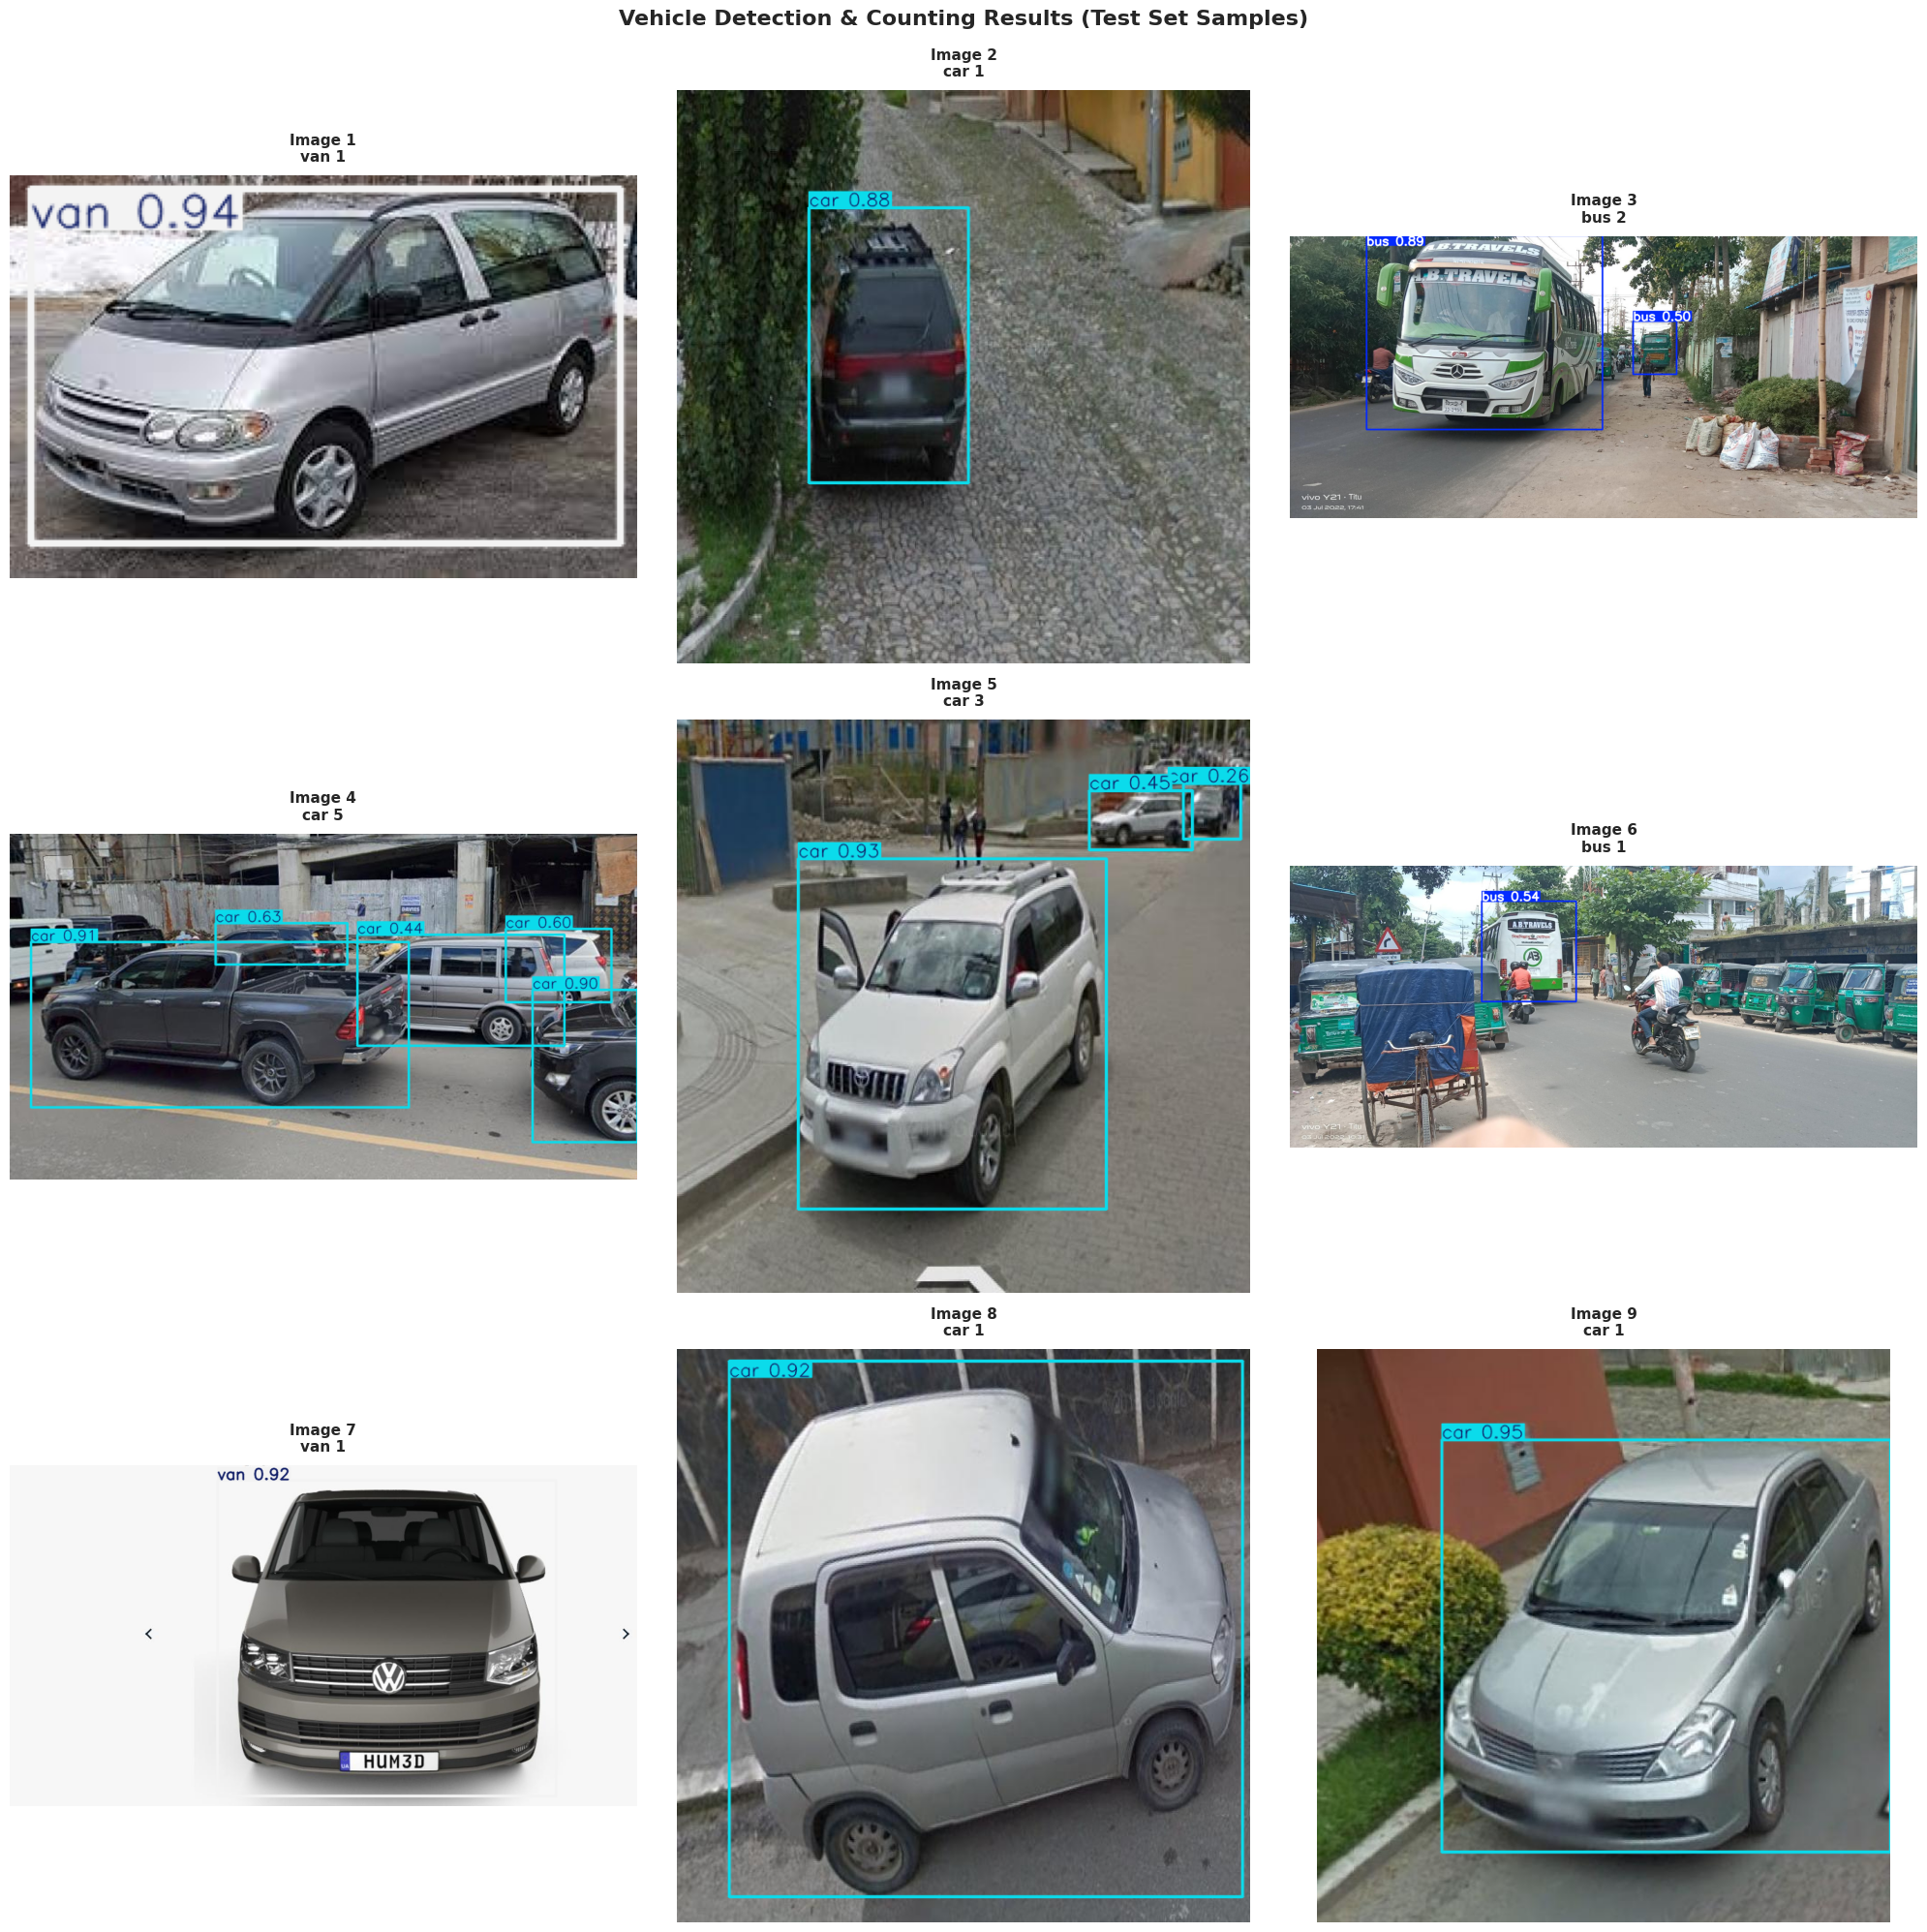


✓ Visualisasi counting results disimpan: 06_counting_results.png
✓ Counting results disimpan: vehicle_counting_results.csv

--------------------------------------------------------------------------------
SUMMARY STATISTICS
--------------------------------------------------------------------------------
Total Images Processed : 9
Total Vehicles Detected: 16
  • Bus                : 3
  • Car                : 11
  • Van                : 2
Average per Image      : 1.78

CONFUSION MATRIX & ADDITIONAL ANALYSIS
WARNING ⚠️ 'save_hybrid' is deprecated and will be removed in the future.
Ultralytics 8.3.221 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1249.6±712.2 MB/s, size: 38.8 KB)
val: Scanning /content/vehicle-detection-1/valid/labels.cache... 287 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 287/287 460.0Kit/s 0.0s
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 19, len(boxes) = 427. To r

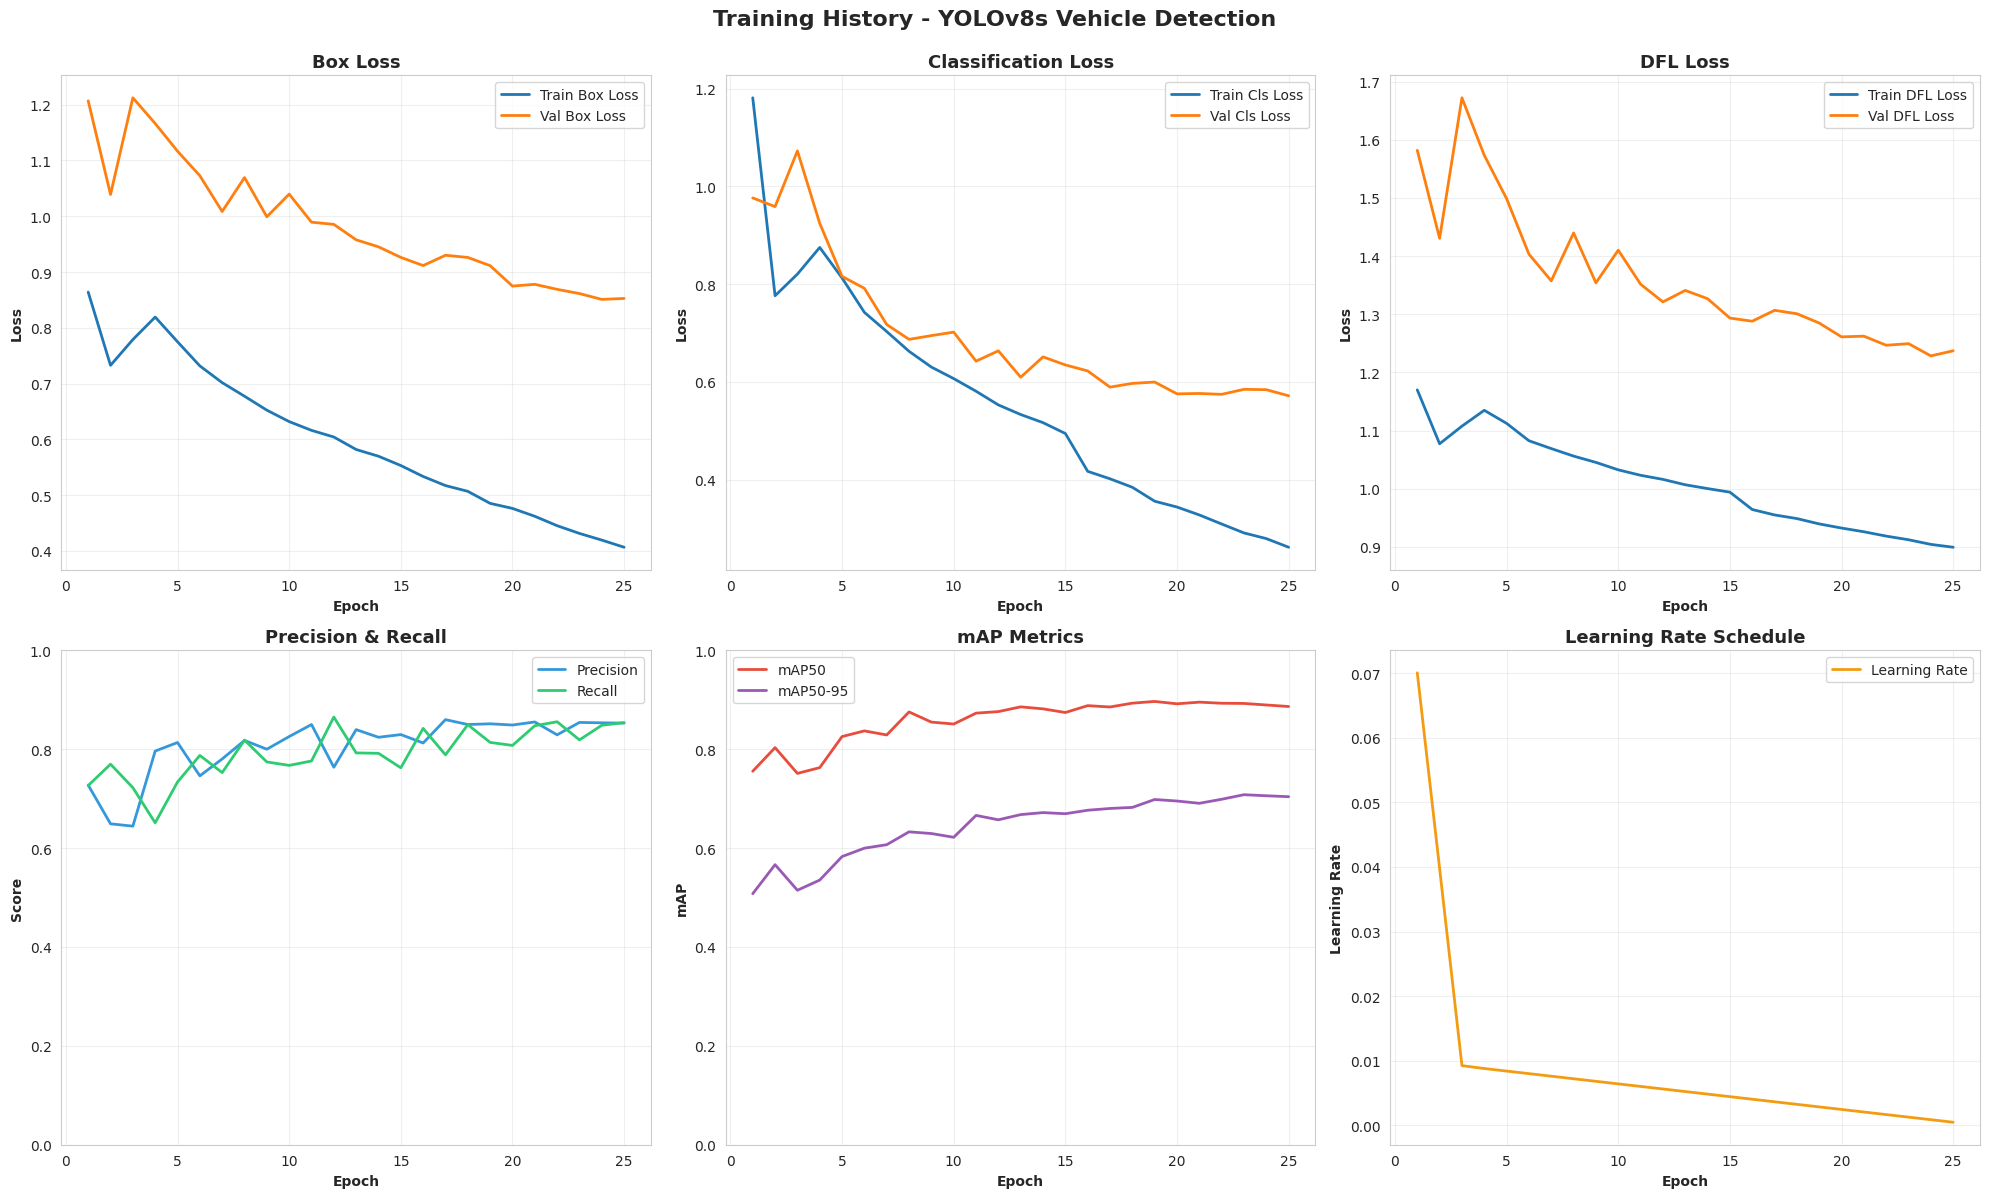

✓ Training history visualization disimpan: 07_training_history.png

FINAL SUMMARY

📊 DATASET SUMMARY
--------------------------------------------------------------------------------
Total Images    : 9725
Total Objects   : 19334
  • Bus         : 4698
  • Car         : 11254
  • Van         : 3382

🎯 MODEL PERFORMANCE
--------------------------------------------------------------------------------
Model           : YOLOv8s
mAP50           : 0.8871
mAP50-95        : 0.7027
Precision       : 0.8182
Recall          : 0.8645

📁 FILES GENERATED
--------------------------------------------------------------------------------
  ✓ 01_data_distribution.png                 (0.29 MB)
  ✓ 02_class_distribution.png                (0.42 MB)
  ✓ 03_image_size_distribution.png           (0.24 MB)
  ✓ 04_sample_images_train.png               (10.67 MB)
  ✓ 05_bbox_analysis.png                     (0.26 MB)
  ✓ 06_counting_results.png                  (15.31 MB)
  ✓ 07_training_history.png              

In [7]:
# =====================================================================================================
# 7. EVALUASI MODEL
# =====================================================================================================

print("\n" + "="*80)
print("EVALUASI MODEL")
print("="*80)

# Load best model
best_model_path = f'{PROJECT_NAME}/{RUN_NAME}/weights/best.pt'
model_best = YOLO(best_model_path)
print(f"✓ Best model loaded from: {best_model_path}")

# Validate on validation set
print("\n📊 Running validation on validation set...")
metrics = model_best.val()

print("\n" + "-"*80)
print("VALIDATION METRICS")
print("-" * 80)
print(f"mAP50           : {metrics.box.map50:.4f}")
print(f"mAP50-95        : {metrics.box.map:.4f}")
print(f"Precision       : {metrics.box.mp:.4f}")
print(f"Recall          : {metrics.box.mr:.4f}")
print(f"F1-Score        : {2 * (metrics.box.mp * metrics.box.mr) / (metrics.box.mp + metrics.box.mr):.4f}")

# Per-class metrics
print("\n" + "-"*80)
print("PER-CLASS METRICS (mAP50)")
print("-" * 80)
for i, class_name in enumerate(model_best.names.values()):
    if i < len(metrics.box.maps):
        print(f"  {class_name:8} : {metrics.box.maps[i]:.4f}")

# Visualisasi metrics
print("\n✓ Training metrics saved in: {}/{}".format(PROJECT_NAME, RUN_NAME))

# =====================================================================================================
# 8. PREDIKSI PADA TEST SET
# =====================================================================================================

print("\n" + "="*80)
print("PREDIKSI PADA TEST SET")
print("="*80)

test_images_path = os.path.join(DATASET_PATH, "test/images")

if os.path.exists(test_images_path):
    print(f"\nRunning predictions on test set...")
    print(f"Test images path: {test_images_path}")

    test_results = model_best.predict(
        source=test_images_path,
        save=True,
        project=PROJECT_NAME,
        name='test_predictions',
        conf=0.25,
        iou=0.45,
        verbose=False
    )

    print(f"✓ Test predictions completed")
    print(f"✓ Results saved in: {PROJECT_NAME}/test_predictions")
else:
    print(f"✗ Test images path not found: {test_images_path}")

# =====================================================================================================
# 9. ANALISIS & SISTEM COUNTING
# =====================================================================================================

print("\n" + "="*80)
print("ANALISIS & SISTEM COUNTING KENDARAAN")
print("="*80)

def count_vehicles_in_image(image_path, model, conf_threshold=0.25):
    """
    Fungsi untuk mendeteksi dan menghitung kendaraan dalam gambar

    Args:
        image_path: Path ke gambar
        model: YOLOv8 model
        conf_threshold: Threshold confidence untuk deteksi

    Returns:
        vehicle_counts: Dictionary jumlah kendaraan per class
        results: YOLOv8 results object
    """
    results = model.predict(source=image_path, conf=conf_threshold, verbose=False)

    vehicle_counts = {'bus': 0, 'car': 0, 'van': 0}

    for result in results:
        boxes = result.boxes
        for box in boxes:
            class_id = int(box.cls[0])
            class_name = model.names[class_id]
            if class_name in vehicle_counts:
                vehicle_counts[class_name] += 1

    return vehicle_counts, results[0]

# Test counting system pada sample test images
test_samples = glob.glob(os.path.join(test_images_path, "*.*"))[:9]

if test_samples:
    print(f"\nTesting vehicle counting system pada {len(test_samples)} sample images...")
    print("-" * 80)

    fig, axes = plt.subplots(3, 3, figsize=(20, 20))
    axes = axes.ravel()

    all_predictions = []

    for idx, img_path in enumerate(test_samples):
        counts, result = count_vehicles_in_image(img_path, model_best, conf_threshold=0.25)

        # Plot hasil
        img_with_boxes = result.plot()
        img_with_boxes = cv2.cvtColor(img_with_boxes, cv2.COLOR_BGR2RGB)

        axes[idx].imshow(img_with_boxes)
        axes[idx].axis('off')

        # Format output sesuai requirement
        output_parts = []
        if counts['bus'] > 0:
            output_parts.append(f"bus {counts['bus']}")
        if counts['car'] > 0:
            output_parts.append(f"car {counts['car']}")
        if counts['van'] > 0:
            output_parts.append(f"van {counts['van']}")

        count_str = ", ".join(output_parts) if output_parts else "No vehicles detected"

        axes[idx].set_title(f"Image {idx+1}\n{count_str}",
                           fontweight='bold', fontsize=11, pad=10)

        # Save prediction info
        all_predictions.append({
            'image': os.path.basename(img_path),
            'bus': counts['bus'],
            'car': counts['car'],
            'van': counts['van'],
            'total': sum(counts.values()),
            'output': count_str
        })

        print(f"Image {idx+1:2}: {count_str}")

    plt.suptitle('Vehicle Detection & Counting Results (Test Set Samples)',
                 fontsize=16, fontweight='bold', y=0.995)
    plt.tight_layout()
    plt.savefig('06_counting_results.png', dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()

    print("\n✓ Visualisasi counting results disimpan: 06_counting_results.png")

    # Save predictions to CSV
    df_predictions = pd.DataFrame(all_predictions)
    df_predictions.to_csv('vehicle_counting_results.csv', index=False)
    print("✓ Counting results disimpan: vehicle_counting_results.csv")

    # Summary statistics
    print("\n" + "-"*80)
    print("SUMMARY STATISTICS")
    print("-" * 80)
    print(f"Total Images Processed : {len(all_predictions)}")
    print(f"Total Vehicles Detected: {df_predictions['total'].sum()}")
    print(f"  • Bus                : {df_predictions['bus'].sum()}")
    print(f"  • Car                : {df_predictions['car'].sum()}")
    print(f"  • Van                : {df_predictions['van'].sum()}")
    print(f"Average per Image      : {df_predictions['total'].mean():.2f}")

# =====================================================================================================
# 10. CONFUSION MATRIX & ADDITIONAL ANALYSIS
# =====================================================================================================

print("\n" + "="*80)
print("CONFUSION MATRIX & ADDITIONAL ANALYSIS")
print("="*80)

# Validate dengan save untuk mendapat confusion matrix
val_results = model_best.val(
    data=yaml_path,
    save_json=True,
    save_hybrid=True,
    conf=0.25,
    iou=0.45,
    plots=True
)

print("✓ Confusion matrix and additional plots saved")
print(f"✓ Check folder: {PROJECT_NAME}/{RUN_NAME}")

# =====================================================================================================
# 11. EXPORT MODEL
# =====================================================================================================

print("\n" + "="*80)
print("EXPORT MODEL")
print("="*80)

# Copy best model ke root directory dengan nama standar
export_path = "best_vehicle_detector.pt"
shutil.copy(best_model_path, export_path)

model_size_mb = os.path.getsize(export_path) / (1024*1024)

print(f"✓ Model exported successfully")
print(f"  • Source      : {best_model_path}")
print(f"  • Destination : {export_path}")
print(f"  • Model Size  : {model_size_mb:.2f} MB")
print(f"  • Model Type  : YOLOv8s PyTorch (.pt)")

# Model info
print(f"\n📋 MODEL INFORMATION")
print("-" * 80)
print(f"Model Architecture : YOLOv8s")
print(f"Input Size         : {IMG_SIZE}x{IMG_SIZE}")
print(f"Number of Classes  : {data_config['nc']}")
print(f"Classes            : {', '.join(data_config['names'])}")
print(f"Framework          : Ultralytics YOLOv8")
print(f"Format             : PyTorch (.pt)")
print(f"Optimized for      : Streamlit Deployment")

# =====================================================================================================
# 12. TRAINING HISTORY VISUALIZATION
# =====================================================================================================

print("\n" + "="*80)
print("TRAINING HISTORY VISUALIZATION")
print("="*80)

# Baca results.csv jika ada
results_csv = f'{PROJECT_NAME}/{RUN_NAME}/results.csv'

if os.path.exists(results_csv):
    print(f"Loading training history from: {results_csv}")

    df_results = pd.read_csv(results_csv)
    df_results.columns = df_results.columns.str.strip()  # Remove whitespace

    # Create training history plots
    fig = plt.figure(figsize=(20, 12))

    # Plot 1: Loss curves
    ax1 = plt.subplot(2, 3, 1)
    if 'train/box_loss' in df_results.columns:
        ax1.plot(df_results['epoch'], df_results['train/box_loss'], label='Train Box Loss', linewidth=2)
    if 'val/box_loss' in df_results.columns:
        ax1.plot(df_results['epoch'], df_results['val/box_loss'], label='Val Box Loss', linewidth=2)
    ax1.set_title('Box Loss', fontsize=13, fontweight='bold')
    ax1.set_xlabel('Epoch', fontweight='bold')
    ax1.set_ylabel('Loss', fontweight='bold')
    ax1.legend()
    ax1.grid(alpha=0.3)

    # Plot 2: Class loss
    ax2 = plt.subplot(2, 3, 2)
    if 'train/cls_loss' in df_results.columns:
        ax2.plot(df_results['epoch'], df_results['train/cls_loss'], label='Train Cls Loss', linewidth=2)
    if 'val/cls_loss' in df_results.columns:
        ax2.plot(df_results['epoch'], df_results['val/cls_loss'], label='Val Cls Loss', linewidth=2)
    ax2.set_title('Classification Loss', fontsize=13, fontweight='bold')
    ax2.set_xlabel('Epoch', fontweight='bold')
    ax2.set_ylabel('Loss', fontweight='bold')
    ax2.legend()
    ax2.grid(alpha=0.3)

    # Plot 3: DFL loss
    ax3 = plt.subplot(2, 3, 3)
    if 'train/dfl_loss' in df_results.columns:
        ax3.plot(df_results['epoch'], df_results['train/dfl_loss'], label='Train DFL Loss', linewidth=2)
    if 'val/dfl_loss' in df_results.columns:
        ax3.plot(df_results['epoch'], df_results['val/dfl_loss'], label='Val DFL Loss', linewidth=2)
    ax3.set_title('DFL Loss', fontsize=13, fontweight='bold')
    ax3.set_xlabel('Epoch', fontweight='bold')
    ax3.set_ylabel('Loss', fontweight='bold')
    ax3.legend()
    ax3.grid(alpha=0.3)

    # Plot 4: Precision & Recall
    ax4 = plt.subplot(2, 3, 4)
    if 'metrics/precision(B)' in df_results.columns:
        ax4.plot(df_results['epoch'], df_results['metrics/precision(B)'], label='Precision', linewidth=2, color='#3498db')
    if 'metrics/recall(B)' in df_results.columns:
        ax4.plot(df_results['epoch'], df_results['metrics/recall(B)'], label='Recall', linewidth=2, color='#2ecc71')
    ax4.set_title('Precision & Recall', fontsize=13, fontweight='bold')
    ax4.set_xlabel('Epoch', fontweight='bold')
    ax4.set_ylabel('Score', fontweight='bold')
    ax4.legend()
    ax4.grid(alpha=0.3)
    ax4.set_ylim([0, 1])

    # Plot 5: mAP
    ax5 = plt.subplot(2, 3, 5)
    if 'metrics/mAP50(B)' in df_results.columns:
        ax5.plot(df_results['epoch'], df_results['metrics/mAP50(B)'], label='mAP50', linewidth=2, color='#e74c3c')
    if 'metrics/mAP50-95(B)' in df_results.columns:
        ax5.plot(df_results['epoch'], df_results['metrics/mAP50-95(B)'], label='mAP50-95', linewidth=2, color='#9b59b6')
    ax5.set_title('mAP Metrics', fontsize=13, fontweight='bold')
    ax5.set_xlabel('Epoch', fontweight='bold')
    ax5.set_ylabel('mAP', fontweight='bold')
    ax5.legend()
    ax5.grid(alpha=0.3)
    ax5.set_ylim([0, 1])

    # Plot 6: Learning rate
    ax6 = plt.subplot(2, 3, 6)
    if 'lr/pg0' in df_results.columns:
        ax6.plot(df_results['epoch'], df_results['lr/pg0'], label='Learning Rate', linewidth=2, color='#f39c12')
    ax6.set_title('Learning Rate Schedule', fontsize=13, fontweight='bold')
    ax6.set_xlabel('Epoch', fontweight='bold')
    ax6.set_ylabel('Learning Rate', fontweight='bold')
    ax6.legend()
    ax6.grid(alpha=0.3)

    plt.suptitle('Training History - YOLOv8s Vehicle Detection',
                 fontsize=16, fontweight='bold', y=0.995)
    plt.tight_layout()
    plt.savefig('07_training_history.png', dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()

    print("✓ Training history visualization disimpan: 07_training_history.png")
else:
    print(f"✗ Results CSV not found: {results_csv}")

# =====================================================================================================
# 13. FINAL SUMMARY & DOWNLOAD INSTRUCTIONS
# =====================================================================================================

print("\n" + "="*80)
print("FINAL SUMMARY")
print("="*80)

print("\n📊 DATASET SUMMARY")
print("-" * 80)
print(f"Total Images    : {total_images}")
print(f"Total Objects   : {total_all_objects}")
print(f"  • Bus         : {all_class_totals['bus']}")
print(f"  • Car         : {all_class_totals['car']}")
print(f"  • Van         : {all_class_totals['van']}")

print("\n🎯 MODEL PERFORMANCE")
print("-" * 80)
print(f"Model           : YOLOv8s")
print(f"mAP50           : {metrics.box.map50:.4f}")
print(f"mAP50-95        : {metrics.box.map:.4f}")
print(f"Precision       : {metrics.box.mp:.4f}")
print(f"Recall          : {metrics.box.mr:.4f}")

print("\n📁 FILES GENERATED")
print("-" * 80)
files_generated = [
    "01_data_distribution.png",
    "02_class_distribution.png",
    "03_image_size_distribution.png",
    "04_sample_images_train.png",
    "05_bbox_analysis.png",
    "06_counting_results.png",
    "07_training_history.png",
    "best_vehicle_detector.pt",
    "vehicle_counting_results.csv"
]

for file in files_generated:
    if os.path.exists(file):
        size_mb = os.path.getsize(file) / (1024*1024)
        print(f"  ✓ {file:40} ({size_mb:.2f} MB)")
    else:
        print(f"  ✗ {file:40} (not found)")

print("\n📂 TRAINING FOLDER")
print("-" * 80)
print(f"  Location: {PROJECT_NAME}/{RUN_NAME}/")
print(f"  Contains:")
print(f"    • weights/best.pt (best model)")
print(f"    • weights/last.pt (last checkpoint)")
print(f"    • results.csv (training metrics)")
print(f"    • confusion_matrix.png")
print(f"    • results.png (all metrics)")
print(f"    • And more...")

print("\n" + "="*80)
print("🎉 SELAMAT! TRAINING BERHASIL DISELESAIKAN!")
print("="*80)

## 📥 Download Files

Download semua hasil training dalam format ZIP

In [ ]:
# =====================================================================================================
# 14. DOWNLOAD FILES FOR GOOGLE DRIVE
# =====================================================================================================

print("\n" + "="*80)
print("PERSIAPAN FILE UNTUK DOWNLOAD")
print("="*80)

# Create a folder for all outputs
output_folder = "vehicle_detection_outputs"
os.makedirs(output_folder, exist_ok=True)

# List of files to copy
files_to_copy = [
    "01_data_distribution.png",
    "02_class_distribution.png",
    "03_image_size_distribution.png",
    "04_sample_images_train.png",
    "05_bbox_analysis.png",
    "06_counting_results.png",
    "07_training_history.png",
    "best_vehicle_detector.pt",
    "vehicle_counting_results.csv"
]

print("\nMengumpulkan file ke folder output...")
copied_files = []
for file in files_to_copy:
    if os.path.exists(file):
        shutil.copy(file, os.path.join(output_folder, file))
        copied_files.append(file)
        print(f"  ✓ {file}")
    else:
        print(f"  ✗ {file} (tidak ditemukan)")

# Copy training results
training_folder = f"{PROJECT_NAME}/{RUN_NAME}"
if os.path.exists(training_folder):
    # Copy confusion matrix
    confusion_matrix = os.path.join(training_folder, "confusion_matrix.png")
    if os.path.exists(confusion_matrix):
        shutil.copy(confusion_matrix, os.path.join(output_folder, "08_confusion_matrix.png"))
        print(f"  ✓ 08_confusion_matrix.png")

    # Copy results.png
    results_png = os.path.join(training_folder, "results.png")
    if os.path.exists(results_png):
        shutil.copy(results_png, os.path.join(output_folder, "09_training_results.png"))
        print(f"  ✓ 09_training_results.png")

    # Copy results.csv
    results_csv_path = os.path.join(training_folder, "results.csv")
    if os.path.exists(results_csv_path):
        shutil.copy(results_csv_path, os.path.join(output_folder, "training_metrics.csv"))
        print(f"  ✓ training_metrics.csv")

    # Copy best and last weights
    weights_folder = os.path.join(training_folder, "weights")
    if os.path.exists(weights_folder):
        best_pt = os.path.join(weights_folder, "best.pt")
        last_pt = os.path.join(weights_folder, "last.pt")

        if os.path.exists(best_pt):
            shutil.copy(best_pt, os.path.join(output_folder, "weights_best.pt"))
            print(f"  ✓ weights_best.pt (backup)")

        if os.path.exists(last_pt):
            shutil.copy(last_pt, os.path.join(output_folder, "weights_last.pt"))
            print(f"  ✓ weights_last.pt (last checkpoint)")


PERSIAPAN FILE UNTUK DOWNLOAD

Mengumpulkan file ke folder output...
  ✓ 01_data_distribution.png
  ✓ 02_class_distribution.png
  ✓ 03_image_size_distribution.png
  ✓ 04_sample_images_train.png
  ✓ 05_bbox_analysis.png
  ✓ 06_counting_results.png
  ✓ 07_training_history.png
  ✓ best_vehicle_detector.pt
  ✓ vehicle_counting_results.csv
  ✓ 08_confusion_matrix.png
  ✓ 09_training_results.png
  ✓ training_metrics.csv
  ✓ weights_best.pt (backup)
  ✓ weights_last.pt (last checkpoint)
